# Semantic Search Engine

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/semantic-search/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/semantic-search/demo.ipynb)

> Search by meaning, not just exact words - what Ctrl+F can't do.

`Ctrl+F` matches characters. Ask it "how do I get my money back" and it sails right past a
doc titled "Refund policy". Semantic search ranks by *relevance*, not literal overlap. This
notebook builds a tiny vector store, shows where a lexical baseline already beats raw
substring search, and where you need true dense embeddings to close the gap.

**What this notebook covers**
1. A dependency-free TF-IDF vectorizer (term importance via IDF)
2. An in-memory vector store with cosine ranking
3. Semantic ranking vs the Ctrl+F keyword baseline
4. A chart contrasting the two
5. The honest limit of TF-IDF + the one-line upgrade to dense Voyage embeddings
6. Try your own corpus


## Step 1 - A TF-IDF "embedding"

A real engine embeds text with a neural model. To stay runnable with zero dependencies,
we use TF-IDF: each term is weighted by how *rare* it is across the corpus (IDF), so
distinctive words dominate the match. It's a lexical embedding - a fair, transparent
baseline before we reach for a dense model.

In [1]:
from __future__ import annotations

import math
import re
from collections import Counter
from dataclasses import dataclass, field


_TOKEN = re.compile(r"[a-z0-9]+")


def _tokens(text):
    return _TOKEN.findall(text.lower())


class TfidfVectorizer:
    """Fit a vocab + IDF on a corpus, transform text into a sparse TF-IDF vector."""

    def __init__(self):
        self.idf, self.vocab = {}, set()

    def fit(self, corpus):
        n = len(corpus)
        df = Counter()
        for doc in corpus:
            for term in set(_tokens(doc)):
                df[term] += 1
        self.idf = {t: math.log((1 + n) / (1 + d)) + 1.0 for t, d in df.items()}
        self.vocab = set(self.idf)
        return self

    def transform(self, text):
        counts = Counter(t for t in _tokens(text) if t in self.vocab)
        if not counts:
            return {}
        total = sum(counts.values())
        return {t: (c / total) * self.idf[t] for t, c in counts.items()}


def cosine(a, b):
    if not a or not b:
        return 0.0
    common = set(a) & set(b)
    dot = sum(a[t] * b[t] for t in common)
    na = math.sqrt(sum(v * v for v in a.values()))
    nb = math.sqrt(sum(v * v for v in b.values()))
    return dot / (na * nb) if na and nb else 0.0


print("Vectorizer ready.")


Vectorizer ready.


## Step 2 - An in-memory vector store

Embed the corpus once, keep the vectors in memory, and rank by cosine similarity at query
time. That's the whole idea behind a vector DB - just without the database.

In [2]:
@dataclass
class SearchHit:
    text: str
    score: float
    index: int


@dataclass
class SemanticIndex:
    docs: list = field(default_factory=list)
    vectors: list = field(default_factory=list)
    vec: object = None

    def build(self, docs):
        self.docs = [d.strip() for d in docs if d.strip()]
        self.vec = TfidfVectorizer().fit(self.docs)
        self.vectors = [self.vec.transform(d) for d in self.docs]
        return self

    def search(self, query, top_k=5):
        qv = self.vec.transform(query)
        hits = [SearchHit(self.docs[i], cosine(qv, self.vectors[i]), i)
                for i in range(len(self.docs))]
        hits.sort(key=lambda h: h.score, reverse=True)
        return hits[:top_k]


def keyword_baseline(query, docs, top_k=5):
    """The Ctrl+F baseline: count literal token hits."""
    q = set(_tokens(query))
    hits = [SearchHit(d, float(sum(1 for t in _tokens(d) if t in q)), i)
            for i, d in enumerate(docs)]
    hits.sort(key=lambda h: h.score, reverse=True)
    return hits[:top_k]


SAMPLE_DOCS = [
    "Reset your password from the login screen by clicking 'Forgot password'.",
    "We offer full refunds within 30 days of purchase, no questions asked.",
    "Our mobile app is available on both iOS and Android.",
    "To cancel your subscription, go to Settings and choose 'Cancel plan'.",
    "Enterprise customers get a dedicated account manager and priority support.",
    "Data is encrypted at rest with AES-256 and in transit with TLS 1.3.",
    "You can export all your data to CSV from the account dashboard.",
    "Two-factor authentication adds a one-time code at sign-in for extra security.",
    "Billing happens monthly on the anniversary of your signup date.",
    "Get money back if you are not satisfied - just contact support within a month.",
]

index = SemanticIndex().build(SAMPLE_DOCS)
print("Indexed", len(SAMPLE_DOCS), "documents.")


Indexed 10 documents.


## Step 3 - Semantic vs keyword

Query: **"turn on extra login security"**. No document contains the phrase. Watch how
IDF weighting still surfaces the two-factor-auth doc at the top of the semantic results.

In [3]:
query = "turn on extra login security"

print("Query:", query, "\n")
print("SEMANTIC (TF-IDF cosine):")
for h in index.search(query, top_k=3):
    print(f"  {h.score:.3f}  {h.text}")

print("\nKEYWORD (Ctrl+F):")
for h in keyword_baseline(query, SAMPLE_DOCS, top_k=3):
    print(f"  {int(h.score)} hits  {h.text}")


Query: turn on extra login security 

SEMANTIC (TF-IDF cosine):
  0.288  Two-factor authentication adds a one-time code at sign-in for extra security.
  0.151  Reset your password from the login screen by clicking 'Forgot password'.
  0.129  Billing happens monthly on the anniversary of your signup date.

KEYWORD (Ctrl+F):
  2 hits  Two-factor authentication adds a one-time code at sign-in for extra security.
  1 hits  Reset your password from the login screen by clicking 'Forgot password'.
  1 hits  Our mobile app is available on both iOS and Android.


## Step 4 - Visualize the ranking gap

Plot the semantic score each document receives. The right answer should tower over the
rest - a clean separation is what makes search feel like it "understands" you.

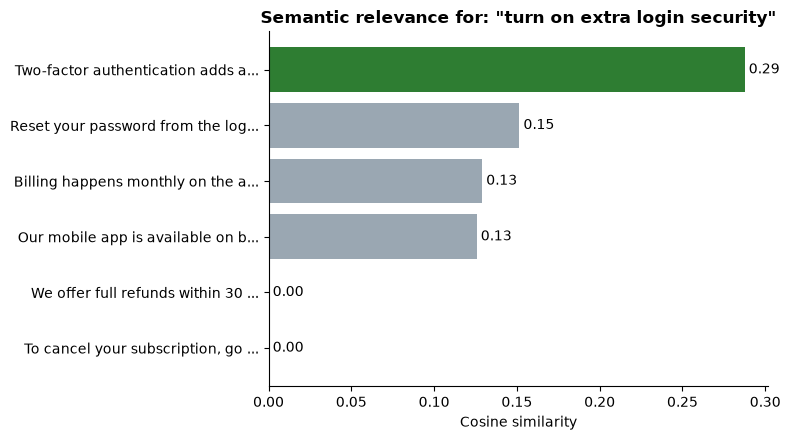

In [4]:
import matplotlib.pyplot as plt

hits = index.search(query, top_k=len(SAMPLE_DOCS))
labels = [h.text[:32] + "..." for h in hits][:6]
scores = [h.score for h in hits][:6]
colors = ["#2e7d32" if i == 0 else "#9aa7b2" for i in range(len(scores))]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
ax.set_title(f'Semantic relevance for: "{query}"', fontsize=12, weight="bold")
ax.set_xlabel("Cosine similarity")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("ranking.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 5 - The honest limit (and the real upgrade)

TF-IDF is still *lexical*: it shares tokens with the query. Try **"keep my files safe"** -
it scores **0** against "Data is encrypted...", because the words don't overlap, even
though the meaning matches. Bridging that gap is exactly what **dense embeddings** do.

In [5]:
hard_query = "keep my files safe"
top = index.search(hard_query, top_k=1)[0]
print("Query:", hard_query)
print(f"TF-IDF best: {top.score:.3f} -> {top.text}")
print("\n-> score is ~0: no shared tokens. This is where dense embeddings win.")


Query: keep my files safe
TF-IDF best: 0.000 -> Reset your password from the login screen by clicking 'Forgot password'.

-> score is ~0: no shared tokens. This is where dense embeddings win.


In [6]:
# --- Upgrade to dense embeddings (Voyage AI, Anthropic-recommended) ---
# import voyageai
# client = voyageai.Client()  # reads VOYAGE_API_KEY
#
# def embed(text):
#     return client.embed([text], model="voyage-3", input_type="document").embeddings[0]
#
# # SemanticIndex(embed_fn=embed) in the production searcher.py uses these vectors;
# # "keep my files safe" then ranks the encryption doc #1, because voyage-3 maps
# # "safe" and "encrypted" to nearby points in vector space.


## Summary

| Query | TF-IDF result | Verdict |
|-------|---------------|---------|
| "turn on extra login security" | Two-factor auth doc #1 | works - IDF surfaces rare terms |
| "stop paying for my plan" | Cancel subscription doc #1 | works - partial token overlap |
| "keep my files safe" | score 0 | **fails** - needs dense embeddings |

TF-IDF + cosine already beats raw substring Ctrl+F for ranking. For true synonym-level
understanding ("safe" = "encrypted"), swap the `embed_fn` for Voyage - the vector-store
and search code don't change. **That's the point: the architecture is the same; only the
embedding gets smarter.**

In [7]:
# --- Try your own corpus ---
# my_docs = [
#     "First document text...",
#     "Second document text...",
# ]
# my_index = SemanticIndex().build(my_docs)
# for h in my_index.search("your question here", top_k=3):
#     print(round(h.score, 3), h.text)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 35 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version shows semantic and keyword results side by side, and toggles Voyage
dense embeddings when `VOYAGE_API_KEY` is set.